In [2]:
!nvidia-smi

Mon Sep  7 15:23:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os, json

os.makedirs('/root/.kaggle', exist_ok=True)

api_token = {
    "username": os.environ.get("KAGGLE_USERNAME", ""),
    "key": os.environ.get("KAGGLE_KEY", "")
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(api_token, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [4]:
!pip install kaggle
!kaggle datasets download -d ajaysonicu/deepfakefusion-399k-realfake-faces
!unzip -q deepfakefusion-399k-realfake-faces.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/ajaysonicu/deepfakefusion-399k-realfake-faces
License(s): MIT
100% 6.67G/6.67G [06:06<00:00, 19.5MB/s]  



In [5]:
!ls -la

total 6996128
drwxr-xr-x 1 root root       4096 Sep  7 15:29 .
drwxr-xr-x 1 root root       4096 Sep  7 15:19 ..
drwxr-xr-x 4 root root       4096 Aug 24 13:27 .config
drwxr-xr-x 3 root root       4096 Sep  7 15:29 data
-rw-r--r-- 1 root root 7164006800 Jun 15 15:59 deepfakefusion-399k-realfake-faces.zip
drwxr-xr-x 1 root root       4096 Aug 24 13:28 sample_data


In [6]:
!find data/ -maxdepth 3 -type d

data/
data/deepfakefusion_v2_sixsource_dataset
data/deepfakefusion_v2_sixsource_dataset/metadata
data/deepfakefusion_v2_sixsource_dataset/test
data/deepfakefusion_v2_sixsource_dataset/test/real
data/deepfakefusion_v2_sixsource_dataset/test/fake
data/deepfakefusion_v2_sixsource_dataset/train
data/deepfakefusion_v2_sixsource_dataset/train/real
data/deepfakefusion_v2_sixsource_dataset/train/fake
data/deepfakefusion_v2_sixsource_dataset/val
data/deepfakefusion_v2_sixsource_dataset/val/real
data/deepfakefusion_v2_sixsource_dataset/val/fake


In [7]:
import os
from pathlib import Path

def examine(dataset_path):
    for dirpath, dirnames, filenames in os.walk(dataset_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

data_path = Path("/content/data/deepfakefusion_v2_sixsource_dataset")
examine(data_path)

There are 4 directories and 0 images in '/content/data/deepfakefusion_v2_sixsource_dataset'.
There are 0 directories and 6 images in '/content/data/deepfakefusion_v2_sixsource_dataset/metadata'.
There are 2 directories and 0 images in '/content/data/deepfakefusion_v2_sixsource_dataset/test'.
There are 0 directories and 19999 images in '/content/data/deepfakefusion_v2_sixsource_dataset/test/real'.
There are 0 directories and 19999 images in '/content/data/deepfakefusion_v2_sixsource_dataset/test/fake'.
There are 2 directories and 0 images in '/content/data/deepfakefusion_v2_sixsource_dataset/train'.
There are 0 directories and 159997 images in '/content/data/deepfakefusion_v2_sixsource_dataset/train/real'.
There are 0 directories and 159997 images in '/content/data/deepfakefusion_v2_sixsource_dataset/train/fake'.
There are 2 directories and 0 images in '/content/data/deepfakefusion_v2_sixsource_dataset/val'.
There are 0 directories and 20000 images in '/content/data/deepfakefusion_v2_si

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image
from tqdm.auto import tqdm

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [12]:
train_path = data_path / "train"
val_path = data_path / "val"
test_path = data_path / "test"

examine(train_path)

There are 2 directories and 0 images in '/content/data/deepfakefusion_v2_sixsource_dataset/train'.
There are 0 directories and 159997 images in '/content/data/deepfakefusion_v2_sixsource_dataset/train/real'.
There are 0 directories and 159997 images in '/content/data/deepfakefusion_v2_sixsource_dataset/train/fake'.


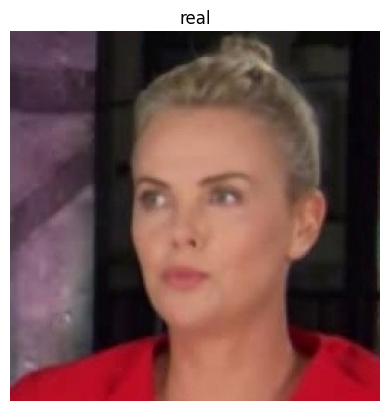

In [13]:
import random

random.seed(42)
path_list = list(train_path.glob("*/*.jpg"))

x = random.choice(path_list)

with Image.open(x) as img:
    plt.imshow(img)
    plt.title(x.parent.stem)
    plt.axis(False)

In [14]:
len(path_list)

319994

In [15]:
img_as_arr = np.asarray(img)
img_as_arr.shape

(256, 256, 3)

In [16]:
data_transform = transforms.Compose([transforms.Resize(size=(128, 128)),
                                    transforms.RandomHorizontalFlip(0.5),
                                    transforms.ToTensor()])

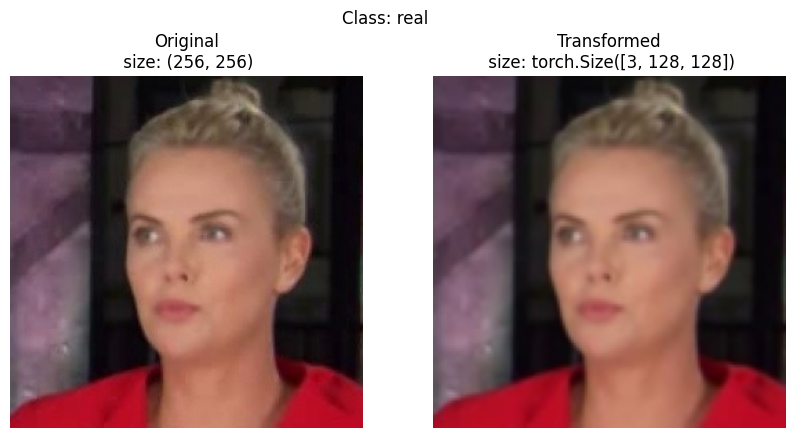

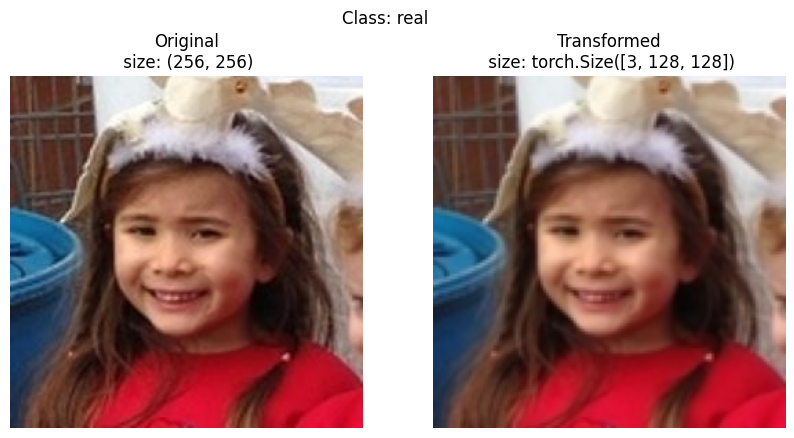

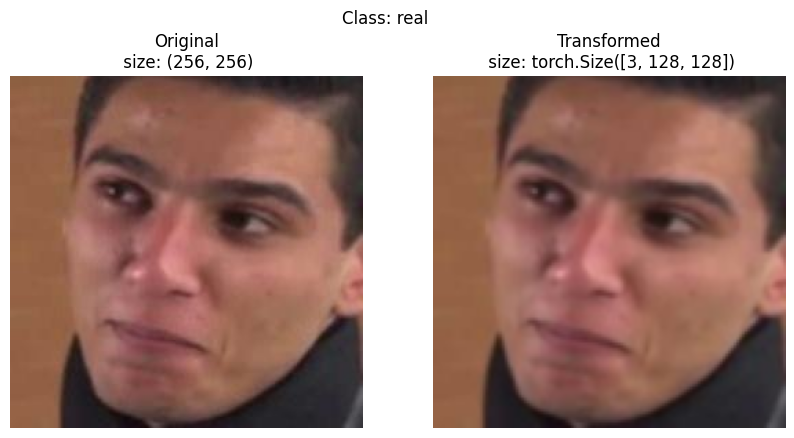

In [17]:
from matplotlib.pyplot import subplots

def plot_transform_imgs(img_paths: list, transform, num_imgs):
    random.seed(42)
    sampled_paths = random.sample(img_paths, k=num_imgs)
    for path in sampled_paths:
        img_class = path.parent.stem
        with Image.open(path) as img:
            fig, ax = subplots(1, 2, figsize=(10, 5))
            ax[0].imshow(img)
            ax[0].set_title(f"Original\n size: {img.size}")
            ax[0].axis("off")

            transformed_img = transform(img)
            ax[1].imshow(transformed_img.permute(1, 2, 0))
            ax[1].set_title(f"Transformed\n size: {transformed_img.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {img_class}")
            plt.show()

plot_transform_imgs(path_list, data_transform, 3)

In [18]:
train_dataset = datasets.ImageFolder(root=train_path, transform=data_transform)
val_dataset = datasets.ImageFolder(root=val_path, transform=data_transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=data_transform)

In [19]:
class_names = train_dataset.classes
class_names

['fake', 'real']

In [20]:
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

val_dataloader = DataLoader(dataset=val_dataset,
                            batch_size=BATCH_SIZE,
                            shuffle=False)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

In [21]:
image, label = next(iter(train_dataloader))

image.shape, label.shape

(torch.Size([32, 3, 128, 128]), torch.Size([32]))

In [22]:
loss_fn = nn.CrossEntropyLoss()

def train_model(model, optimizer, epochs):
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in tqdm(range(epochs)):
        model.train()

        train_loss, train_acc = 0, 0
        for x, y in train_dataloader:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)

            loss = loss_fn(y_pred, y)
            train_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            y_pred_class = torch.argmax(y_pred, dim=1)
            train_acc += (y_pred_class == y).sum().item()

        train_loss = train_loss / len(train_dataloader)
        train_acc = (train_acc / len(train_dataset)) * 100

        model.eval()
        val_loss, val_acc = 0, 0

        with torch.inference_mode():
            for x, y in val_dataloader:
                x, y = x.to(device), y.to(device)
                val_pred = model(x)

                loss = loss_fn(val_pred, y)
                val_loss += loss.item()

                val_pred_labels = val_pred.argmax(dim=1)
                val_acc += (val_pred_labels == y).sum().item()

        val_loss = val_loss / len(val_dataloader)
        val_acc = (val_acc / len(val_dataset)) * 100

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch + 1} | Train Loss {train_loss:.4f} | Train Accuracy {train_acc:.2f}% | Val Loss {val_loss:.4f} | Val Accuracy {val_acc:.2f}%")

    return train_losses, train_accs, val_losses, val_accs


def plot_curves(train_losses, val_losses, train_accs, val_accs):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(train_losses, label="train_loss")
    ax[0].plot(val_losses, label="val_loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Loss")
    ax[0].legend()

    ax[1].plot(train_accs, label="train_acc")
    ax[1].plot(val_accs, label="val_acc")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy (%)")
    ax[1].set_title("Accuracy")
    ax[1].legend()

    plt.show()


def evaluate_model(model):
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for x, y in test_dataloader:
            x, y = x.to(device), y.to(device)
            test_pred = model(x)

            loss = loss_fn(test_pred, y)
            test_loss += loss.item()

            test_pred_labels = test_pred.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item()

    test_loss = test_loss / len(test_dataloader)
    test_acc = (test_acc / len(test_dataset)) * 100

    print(f"Final Test Loss {test_loss:.4f} | Final Test Accuracy {test_acc:.2f}%")
    return test_loss, test_acc


def save_model(model, model_name):
    save_dir = Path("/content/models")
    save_dir.mkdir(parents=True, exist_ok=True)
    save_path = save_dir / model_name
    torch.save(model.state_dict(), save_path)
    print(f"Saved model to {save_path}")
    return save_path

In [23]:
class My_Model(nn.Module):
    def __init__(self, input_shape=3, hidden_units=12, output_shape=4):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=(hidden_units * 32 * 32), out_features=output_shape)
        )

    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

torch.manual_seed(42)
cnn_model = My_Model().to(device)

In [24]:
img_sample, label_sample = next(iter(train_dataloader))
img_sample, label_sample = img_sample.to(device), label_sample.to(device)

cnn_model.eval()
with torch.inference_mode():
    pred = cnn_model(img_sample)
    probs = torch.softmax(pred, dim=1)
    pred_labels = torch.argmax(probs, dim=1)

pred_labels == label_sample

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False], device='cuda:0')

In [25]:
cnn_optimizer = torch.optim.AdamW(params=cnn_model.parameters(), lr=1e-3)

In [26]:
cnn_train_losses, cnn_train_accs, cnn_val_losses, cnn_val_accs = train_model(cnn_model, cnn_optimizer, epochs=3)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1 | Train Loss 0.5714 | Train Accuracy 69.70% | Val Loss 0.5065 | Val Accuracy 74.84%
Epoch 2 | Train Loss 0.4791 | Train Accuracy 76.78% | Val Loss 0.4806 | Val Accuracy 76.73%
Epoch 3 | Train Loss 0.4502 | Train Accuracy 78.54% | Val Loss 0.4482 | Val Accuracy 78.49%


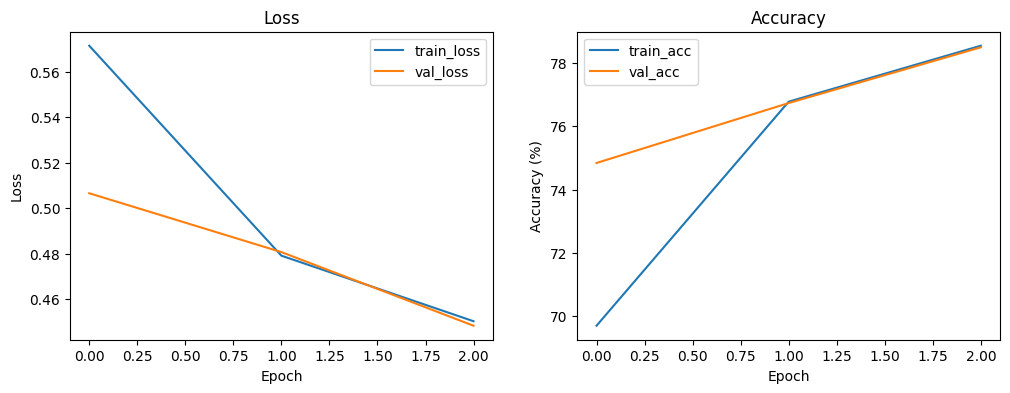

In [27]:
plot_curves(cnn_train_losses, cnn_val_losses, cnn_train_accs, cnn_val_accs)

In [29]:
cnn_test_loss, cnn_test_acc = evaluate_model(cnn_model)

Final Test Loss 0.4452 | Final Test Accuracy 78.51%


In [30]:
save_model(cnn_model, "cnn_model.pth")

Saved model to /content/models/cnn_model.pth


PosixPath('/content/models/cnn_model.pth')

In [ ]:
!python /content/DeepFake-Face-Authenticator/src/train.py \
  --model efficientnet --epochs 3 \
  --resume /content/DeepFake-Face-Authenticator/models/efficientnet_model.pth \
  --data-dir /content/data/deepfakefusion_v2_sixsource_dataset \
  --models-dir /content/DeepFake-Face-Authenticator/models \
  --results-dir /content/DeepFake-Face-Authenticator/results

[INFO] Using device: cuda
[INFO] Classes: ['fake', 'real']
[INFO] Loaded weights-only file from /content/DeepFake-Face-Authenticator/models/efficientnet_model.pth — starting fresh optimizer, epoch counter reset to 1.
  0% 0/3 [00:00<?, ?it/s]Epoch 1 | train_loss: 0.1550 | train_acc: 93.37% | val_loss: 0.1349 | val_acc: 93.96%
[INFO] Saved checkpoint to: /content/DeepFake-Face-Authenticator/models/efficientnet_checkpoint.pth
 33% 1/3 [14:48<29:36, 888.41s/it]